Sales and Revenue Analysis

Phase 1: Data loading, inspecting and transforming using Pandas

In [18]:
import pandas as pd

In [19]:
#read/load the kaggle 'superstore' dataset
df = pd.read_csv("superstore.csv")

In [20]:
#inspecting the data

df.shape
print(df.head())
print(df.tail())

   Row ID        Order ID  Order Date   Ship Date       Ship Mode Customer ID  \
0       1  CA-2017-152156  08/11/2017  11/11/2017    Second Class    CG-12520   
1       2  CA-2017-152156  08/11/2017  11/11/2017    Second Class    CG-12520   
2       3  CA-2017-138688  12/06/2017  16/06/2017    Second Class    DV-13045   
3       4  US-2016-108966  11/10/2016  18/10/2016  Standard Class    SO-20335   
4       5  US-2016-108966  11/10/2016  18/10/2016  Standard Class    SO-20335   

     Customer Name    Segment        Country             City       State  \
0      Claire Gute   Consumer  United States        Henderson    Kentucky   
1      Claire Gute   Consumer  United States        Henderson    Kentucky   
2  Darrin Van Huff  Corporate  United States      Los Angeles  California   
3   Sean O'Donnell   Consumer  United States  Fort Lauderdale     Florida   
4   Sean O'Donnell   Consumer  United States  Fort Lauderdale     Florida   

   Postal Code Region       Product ID         Cat

In [21]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 9800 entries, 0 to 9799
Data columns (total 18 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   Row ID         9800 non-null   int64  
 1   Order ID       9800 non-null   str    
 2   Order Date     9800 non-null   str    
 3   Ship Date      9800 non-null   str    
 4   Ship Mode      9800 non-null   str    
 5   Customer ID    9800 non-null   str    
 6   Customer Name  9800 non-null   str    
 7   Segment        9800 non-null   str    
 8   Country        9800 non-null   str    
 9   City           9800 non-null   str    
 10  State          9800 non-null   str    
 11  Postal Code    9789 non-null   float64
 12  Region         9800 non-null   str    
 13  Product ID     9800 non-null   str    
 14  Category       9800 non-null   str    
 15  Sub-Category   9800 non-null   str    
 16  Product Name   9800 non-null   str    
 17  Sales          9800 non-null   float64
dtypes: float64(2), int6

found Order Date and Ship Date in 'string' data type instead of 'date and time' format

In [22]:
#checking if there are any missing values
df.isnull().sum()

Row ID            0
Order ID          0
Order Date        0
Ship Date         0
Ship Mode         0
Customer ID       0
Customer Name     0
Segment           0
Country           0
City              0
State             0
Postal Code      11
Region            0
Product ID        0
Category          0
Sub-Category      0
Product Name      0
Sales             0
dtype: int64

found Postal Code containing 11 missing values

In [23]:
#checking if there are duplicates
df.duplicated().sum()

np.int64(0)

no duplicates found

In [24]:
#converting data type
df["Order Date"] = pd.to_datetime(
    df["Order Date"],
    format="%d/%m/%Y"
)

df["Ship Date"] = pd.to_datetime(
    df["Ship Date"],
    format="%d/%m/%Y"
)

In [26]:
df[["Order Date", "Ship Date"]].dtypes

Order Date    datetime64[us]
Ship Date     datetime64[us]
dtype: object

In [27]:
(df["Ship Date"] < df["Order Date"]).sum()

np.int64(0)

In [28]:
df["Year"] = df["Order Date"].dt.year
df["Month"] = df["Order Date"].dt.month
df["Month Name"] = df["Order Date"].dt.month_name()

In [29]:
df["Shipping Days"] = (
    df["Ship Date"] - df["Order Date"]
).dt.days

In [30]:
df["Shipping Days"].describe()

count    9800.000000
mean        3.961122
std         1.749614
min         0.000000
25%         3.000000
50%         4.000000
75%         5.000000
max         7.000000
Name: Shipping Days, dtype: float64

In [32]:
(df["Sales"] < 0).sum()

np.int64(0)

In [ ]:
(df["Sales"] == 0).sum()

np.int64(0)

We have:
9,800 transaction/product rows
4,922 unique order.
So there are 1,861 unique products represented.

In [36]:
#saving the cleaned dataset

df.to_csv("superstore_cleaned.csv", index=False)

Phase 2: Sales Analysis

In [38]:
#total sales made
print(df["Sales"].sum())

2261536.7827


In [39]:
#how many orders received

df["Order ID"].nunique()

4922

In [40]:
#products represented

df["Product ID"].nunique()

1861

In [42]:
#average sales value per transaction row

print(df["Sales"].mean())

230.76905945918367


In [56]:
#Which product category generates the most sales

category_sales = df.groupby("Category")["Sales"].sum()
category_sales.sort_values(ascending=False)

Category
Technology         827455.8730
Furniture          728658.5757
Office Supplies    705422.3340
Name: Sales, dtype: float64

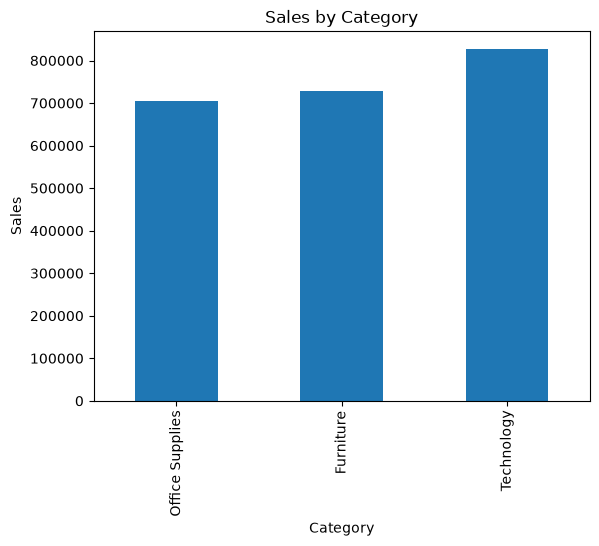

In [60]:
#visualizing the findings

import matplotlib.pyplot as plt

category_sales.sort_values().plot(kind="bar")
plt.title("Sales by Category")
plt.xlabel("Category")
plt.ylabel("Sales")
plt.show()

In [58]:
#sales by region

region_sales = df.groupby("Region")["Sales"].sum()
region_sales.sort_values(ascending=False)

Region
West       710219.6845
East       669518.7260
Central    492646.9132
South      389151.4590
Name: Sales, dtype: float64

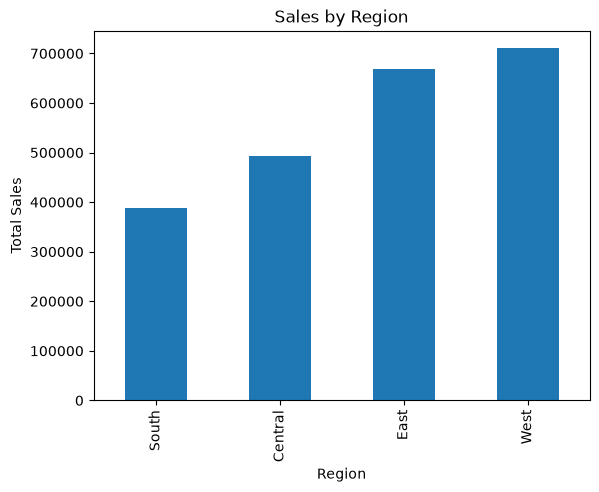

In [59]:
region_sales.sort_values().plot(kind="bar")

plt.title("Sales by Region")
plt.xlabel("Region")
plt.ylabel("Total Sales")
plt.show()

In [61]:
#How does sales performance change month by month?

monthly_sales = df.groupby(["Year", "Month"])["Sales"].sum().reset_index()

In [62]:
monthly_sales.head(10)

,Year,Month,Sales
0,2015,1,14205.7070
1,2015,2,4519.8920
2,2015,3,55205.7970
3,2015,4,27906.8550
4,2015,5,23644.3030
5,2015,6,34322.9356
6,2015,7,33781.5430
7,2015,8,27117.5365
8,2015,9,81623.5268
9,2015,10,31453.3930


In [64]:
monthly_sales["Month Date"] = pd.to_datetime(
    monthly_sales["Year"].astype(str) + "-" +
    monthly_sales["Month"].astype(str) + "-01"
)

In [65]:
monthly_sales = monthly_sales.sort_values("Month Date")

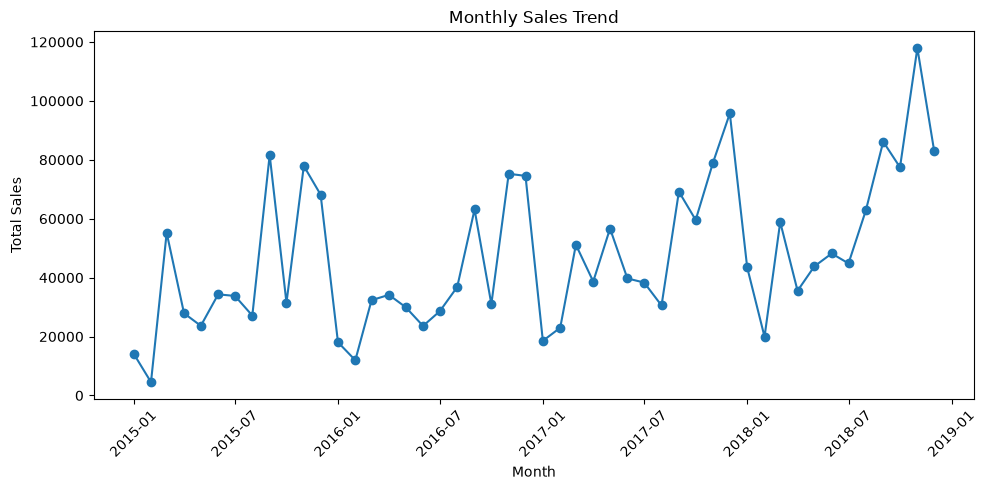

In [66]:
plt.figure(figsize=(10, 5))

plt.plot(
    monthly_sales["Month Date"],
    monthly_sales["Sales"],
    marker="o"
)

plt.title("Monthly Sales Trend")
plt.xlabel("Month")
plt.ylabel("Total Sales")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

Monthly Sales Trend

We wanted to understand **how sales change from month to month over the years**. First, we grouped the data by both `Year` and `Month` and summed the `Sales` to get total sales for each month. We then created a proper `Month Date` column so that months from different years would be placed correctly on one continuous timeline. After sorting the data chronologically, we used Matplotlib to create a line chart with **time on the X-axis and sales on the Y-axis**.

The monthly sales trend shows fluctuations in sales across the years, with certain months showing noticeably higher or lower sales. This helps identify periods of stronger and weaker sales performance.

In [67]:
#top 5 products that generate most sales

top_products = (
    df.groupby("Product Name")["Sales"]
      .sum()
      .sort_values(ascending=False)
      .head(5)
)

top_products

Product Name
Canon imageCLASS 2200 Advanced Copier                                          61599.824
Fellowes PB500 Electric Punch Plastic Comb Binding Machine with Manual Bind    27453.384
Cisco TelePresence System EX90 Videoconferencing Unit                          22638.480
HON 5400 Series Task Chairs for Big and Tall                                   21870.576
GBC DocuBind TL300 Electric Binding System                                     19823.479
Name: Sales, dtype: float64

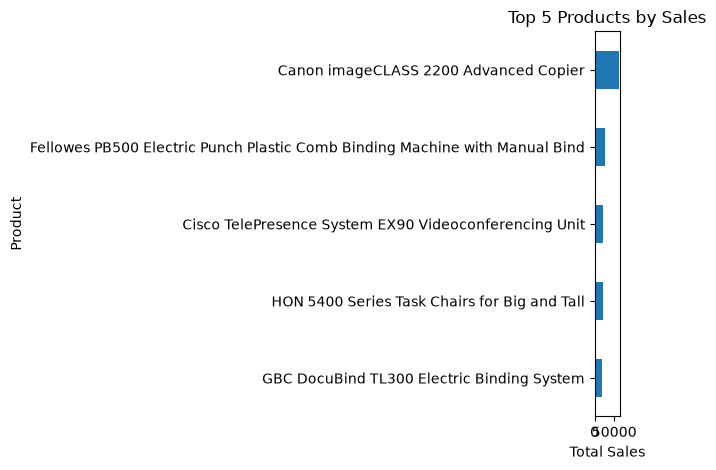

In [68]:
top_products.sort_values().plot(kind="barh")

plt.title("Top 5 Products by Sales")
plt.xlabel("Total Sales")
plt.ylabel("Product")
plt.tight_layout()
plt.show()

# Project Summary — Sales & Revenue Analysis

## 1. Data Loading
Loaded the Superstore retail dataset using `pd.read_csv()` and stored it in a Pandas DataFrame.

- Dataset size: **9,800 rows and 18 columns**
- Used `df.head()` and `df.tail()` to preview the data.
- Used `df.info()` to understand the column names, data types, and missing values.

## 2. Data Inspection & Cleaning
Checked the dataset for common data-quality problems before analysis.

- `df.isnull().sum()` → found **11 missing values in Postal Code**. Since Postal Code is not required for our sales analysis, the rows were kept.
- `df.duplicated().sum()` → found **0 duplicate rows**.
- Converted `Order Date` and `Ship Date` from strings to datetime using `pd.to_datetime()` with the correct `%d/%m/%Y` format.
- Checked that no order had a shipping date earlier than its order date → **0 invalid records**.

## 3. Data Transformation
Created additional fields that would be useful for analysis:

- `Year`, `Month`, and `Month Name` → extracted from `Order Date` for time-based analysis.
- `Shipping Days` → calculated the number of days between ordering and shipping.

The dataset contains **4,922 unique orders** and **1,861 unique products**.

## 4. Sales Analysis

### Overall Sales
**Question:** How much sales revenue was generated?

Used:

`df["Sales"].sum()`

**Answer:** Total sales = **2,261,536.78**

Also calculated:
- Unique orders → **4,922**
- Unique products → **1,861**
- Average sales per transaction row → **230.77**

### Category Performance
**Question:** Which product category generates the most sales?

Used `groupby()` and `sum()` to calculate total sales by category.

**Result:**
- Technology → **827,455.87**
- Furniture → **728,658.58**
- Office Supplies → **705,422.33**

Technology generated the highest total sales.

### Regional Performance
**Question:** Which region generates the most sales?

Used `groupby("Region")["Sales"].sum()` and sorted the results.

**Result:**
- West → **710,219.68**
- East → **669,518.73**
- Central → **492,646.91**
- South → **389,151.46**

The West region generated the highest total sales.

### Monthly Sales Trend
**Question:** How does sales performance change month by month?

Grouped sales by `Year` and `Month`, then created a proper `Month Date` column so the data could be plotted chronologically.

Used Matplotlib to create a line chart showing **monthly sales over time**.

This helps identify higher/lower sales periods and overall changes in sales over time.

### Top 5 Products
**Question:** Which individual products generate the highest total sales?

Grouped by `Product Name`, summed sales, sorted from highest to lowest, and selected the first five using `.head(5)`.

**Top 5 by total sales:**
1. Canon imageCLASS 2200 Advanced Copier
2. Fellowes PB500 Electric Punch Plastic Comb Binding Machine
3. Cisco TelePresence System EX90 Videoconferencing Unit
4. HON 5400 Series Task Chairs for Big and Tall
5. GBC DocuBind TL300 Electric Binding System

These are the top products **by total sales revenue**, not necessarily the products purchased most frequently or the most profitable products.

## 5. Visualization
Used **Matplotlib** to visualize the analysis, including:

- Sales by Category
- Sales by Region
- Monthly Sales Trend
- Top 5 Products by Sales

The purpose of these visualizations was to make the calculated results easier to understand and identify useful business patterns.

## Overall
The analysis transformed the raw Superstore dataset into a validated dataset and used Pandas to answer key business questions about **overall sales, category performance, regional performance, sales trends, and top-performing products**.